In [1]:
!pip install pyspark

In [2]:
import os

dest_dir = "/content/data"
if not os.path.exists(dest_dir):
    os.makedirs(dest_dir)

# Set a new, temporary cache directory to bypass previous cache
os.environ["KAGGLEHUB_CACHE"] = dest_dir

In [3]:
import kagglehub

# Download the sales dataset
path = kagglehub.dataset_download("ssssws/chocolate-sales-dataset-2023-2024", force_download=True)

print("Path to dataset files:", path)

100%|██████████| 23.3M/23.3M [00:00<00:00, 179MB/s]

Extracting files...


Path to dataset files: /content/data/datasets/ssssws/chocolate-sales-dataset-2023-2024/versions/2


In [26]:
sales_csv = path + "/sales.csv"

# Pandas mode (no cluster)
import pandas as pd
import time

# Get number of processors
num_cpus = os.cpu_count()
print(f"Number of CPUs: {num_cpus}")

# Data loading performance

start_time = time.perf_counter()
ldf = pd.read_csv(sales_csv)
#ldf.head()
ldf_load_time = time.perf_counter() - start_time
print(f"Time taken: {ldf_load_time:0.4f} seconds")

Number of CPUs: 2
Time taken: 2.8388 seconds


In [14]:
# Groupby performance

start_time = time.perf_counter()

ldf_sum_by_product = ldf.groupby('product_id').sum()
#ldf_sum_by_product.head()

ldf_time = time.perf_counter() - start_time
print(f"Time taken: {ldf_time:0.4f} seconds")

Time taken: 6.5006 seconds


In [15]:
# Initiate PySpark session
from pyspark.sql import SparkSession

# Create a Spark Session
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Colab_PySpark_Test") \
    .getOrCreate()

# Check to see if it worked
spark.getActiveSession()

In [29]:
# Example: Read a CSV file into a PySpark DataFrame
start_time = time.perf_counter()

df = spark.read.csv(sales_csv, header=True, inferSchema=True)
# Verify by showing the schema and first few rows
#df.printSchema()
#df.show()

cdf_load_time = time.perf_counter() - start_time
print(f"Time taken: {cdf_load_time:0.4f} seconds")
load_efficiency = ldf_load_time / (cdf_load_time * num_cpus)
print(f"Data loading efficiency: {load_efficiency:0.4f}")

Time taken: 3.9634 seconds
Data loading efficiency: 0.3581


In [30]:
# GroupBy Product
start_time = time.perf_counter()
by_product = df.groupby('product_id').sum()
#by_product.show()
cdf_sum_time = time.perf_counter() - start_time
print(f"Time taken: {cdf_sum_time:0.4f} seconds")

agg_efficiency = ldf_time / (cdf_sum_time * num_cpus)
print(f"Aggregate efficiency: {agg_efficiency:0.4f}")


Time taken: 0.0378 seconds
Aggregate efficiency: 86.0548


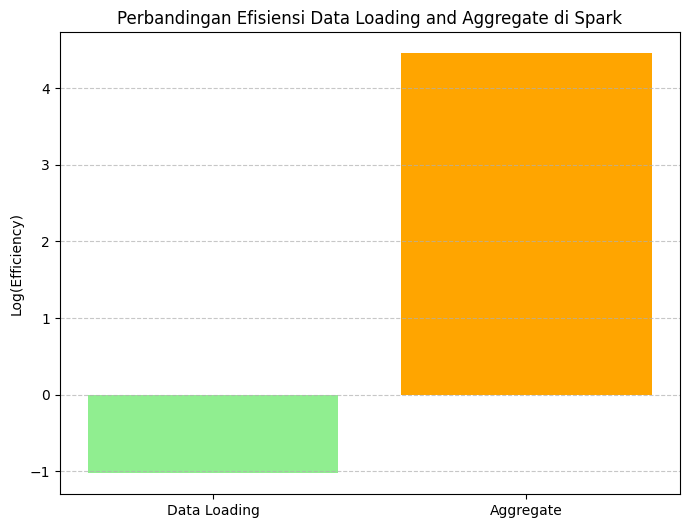

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

log_load_efficiency = np.log(load_efficiency)
log_agg_efficiency = np.log(agg_efficiency)

log_efficiencies = pd.DataFrame({
    'Metric': ['Data Loading', 'Aggregate'],
    'Value': [log_load_efficiency, log_agg_efficiency]
})

plt.figure(figsize=(8, 6))
plt.bar(log_efficiencies['Metric'], log_efficiencies['Value'], color=['lightgreen', 'orange'])
plt.ylabel('Log(Efficiency)')
plt.title('Perbandingan Efisiensi Data Loading and Aggregate di Spark')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# PRAKTIKUM
# Buat grafik efisiensi untuk fungsi agregate yang lain: avg, count, max, min